# 01 — Exploratory Data Analysis (EDA)

Tujuan notebook ini:
1. Pahami distribusi tiap sensor
2. Temukan outlier dan anomali
3. **Kalibrasi threshold KB** (nilai di `config.py` masih placeholder!)
4. Analisis pola failure per komponen
5. Cek korelasi sensor dengan failure

In [2]:
import sys
sys.path.insert(0, '..')  # supaya bisa import config

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from config import RAW_FILES, SENSOR_COLS, COMPONENT_COLS

pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)

## 1. Load data

In [3]:
telemetry = pd.read_csv(RAW_FILES['telemetry'], parse_dates=['datetime'])
errors    = pd.read_csv(RAW_FILES['errors'],    parse_dates=['datetime'])
failures  = pd.read_csv(RAW_FILES['failures'],  parse_dates=['datetime'])
maint     = pd.read_csv(RAW_FILES['maint'],     parse_dates=['datetime'])
machines  = pd.read_csv(RAW_FILES['machines'])

print('Telemetry:', telemetry.shape)
print('Errors:   ', errors.shape)
print('Failures: ', failures.shape)
print('Maint:    ', maint.shape)
print('Machines: ', machines.shape)

Telemetry: (876100, 6)
Errors:    (3919, 3)
Failures:  (761, 3)
Maint:     (3286, 3)
Machines:  (100, 3)


## 2. Distribusi sensor — KALIBRASI THRESHOLD KB DI SINI

In [4]:
# Lihat statistik deskriptif sensor
telemetry[SENSOR_COLS].describe(percentiles=[.01, .05, .25, .75, .95, .99])

,volt,rotate,pressure,vibration
count,876100.000,876100.000,876100.000,876100.000
mean,170.778,446.605,100.859,40.385
std,15.509,52.674,11.049,5.370
min,97.334,138.432,51.237,14.877
1%,135.397,316.766,76.845,28.446
5%,145.614,358.598,83.701,31.864
25%,160.305,412.306,93.498,36.777
75%,181.004,482.177,107.555,43.785
95%,196.549,531.334,119.446,49.383
99%,208.132,565.513,131.701,54.241


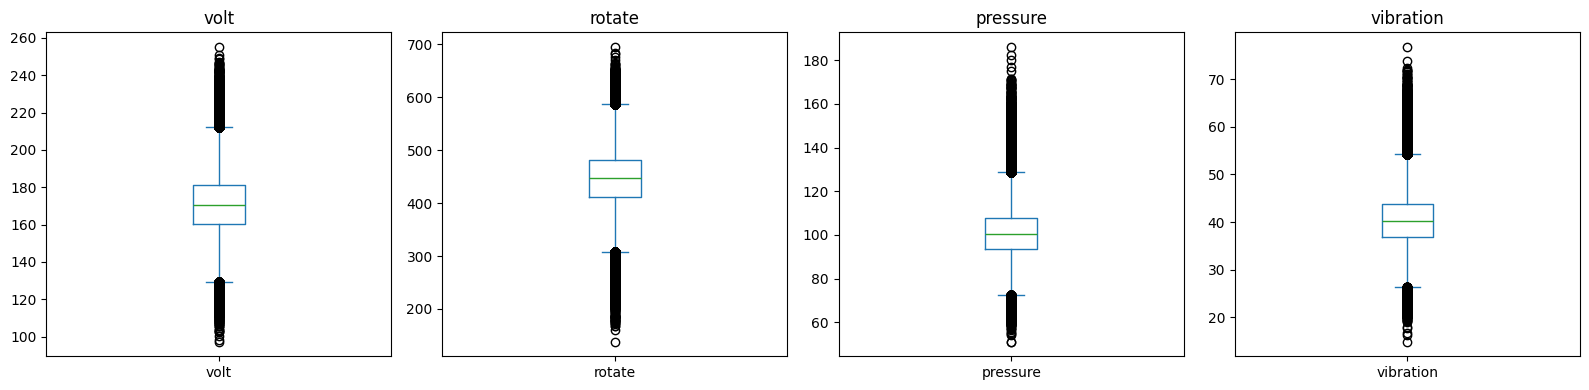

In [5]:
# Boxplot untuk lihat outlier
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, SENSOR_COLS):
    telemetry[col].plot(kind='box', ax=ax)
    ax.set_title(col)
plt.tight_layout()

# TODO: Catat nilai p1 dan p99 sebagai kandidat threshold KB
# Update KB_THRESHOLDS di config.py berdasarkan hasil ini!

## 3. Pola failure per komponen

In [6]:
print('Distribusi failure per komponen:')
print(failures['failure'].value_counts())

print('\nDistribusi maintenance per komponen:')
print(maint['comp'].value_counts())

Distribusi failure per komponen:
failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64

Distribusi maintenance per komponen:
comp
comp2    863
comp4    811
comp3    808
comp1    804
Name: count, dtype: int64


## 4. Distribusi mesin per model

In [7]:
print(machines['model'].value_counts())
print('\nDistribusi usia mesin:')
print(machines['age'].describe())

model
model3    35
model4    32
model2    17
model1    16
Name: count, dtype: int64

Distribusi usia mesin:
count   100.000
mean     11.330
std       5.857
min       0.000
25%       6.750
50%      12.000
75%      16.000
max      20.000
Name: age, dtype: float64


## 5. Korelasi sensor dengan failure
Analisis: apakah nilai sensor tinggi/rendah berkorelasi dengan failure tertentu?

In [8]:
# TODO: window sensor sebelum failure vs sensor normal
# Merge failures dengan telemetry, ambil 24h sebelum failure
# Bandingkan distribusinya
pass